# Modèles IA v5 — Holdout Test Final

## Pourquoi ce notebook ?

Jusqu'à maintenant, on a utilisé le **même test set** pour comparer V1, V2, V3 et V4.
Ce test set est **contaminé** : on a indirectement optimisé le modèle en fonction de ses résultats.

Pour avoir une estimation **HONNÊTE** des performances finales :
- Nouveau split avec `random_state=999` (jamais utilisé avant)
- **30% des données** gardées comme holdout test
- Ce holdout n'a **JAMAIS** été utilisé pendant tout le développement

Le modèle final est entraîné sur les **70% restants** avec la meilleure configuration issue de la V4 :
**Bio + Symptômes + Lifestyle + SMOTE + Scaler**

Les résultats sur ce holdout sont une estimation **NON BIAISÉE** des performances réelles.



---
## Section 0 — Imports & Chargement

In [9]:
import sys
import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'scikit-learn', 'imbalanced-learn', 'pandas',
                       'numpy', 'matplotlib', 'seaborn', 'odfpy'])

0

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE


In [11]:
DATA_PATH = '../data_csv/raw/vitamin_deficiency_disease_dataset_20260123.ods'
df = pd.read_excel(DATA_PATH, engine='odf')

print(f'Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes')
print(f'\nDistribution des classes :')
print(df['disease_diagnosis'].value_counts())

Dataset chargé : 4000 lignes x 34 colonnes

Distribution des classes :
disease_diagnosis
Healthy                 1509
Anemia                  1245
Rickets_Osteomalacia    1029
Night_Blindness          122
Scurvy                    95
Name: count, dtype: int64


---
## Section 1 — Définition des features & Fonction utilitaire

In [13]:
# Meilleure configuration issue de la V4
COLONNE_CIBLE = 'disease_diagnosis'

FEATURES_BIO = [
    'hemoglobin_g_dl',
    'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda',
    'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda',
    'calcium_percent_rda', 'iron_percent_rda',
    'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml'
]

FEATURES_SYMPTOMES = [
    'has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
    'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling',
    'has_memory_problems', 'has_pale_skin'
]

FEATURES_LIFESTYLE = [
    'age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption',
    'exercise_level', 'diet_type', 'sun_exposure',
    'latitude_region', 'income_level'
]

print(f'Features Bio       : {len(FEATURES_BIO)}')
print(f'Features Symptomes : {len(FEATURES_SYMPTOMES)}')
print(f'Features Lifestyle : {len(FEATURES_LIFESTYLE)}')
print(f'Total              : {len(FEATURES_BIO + FEATURES_SYMPTOMES + FEATURES_LIFESTYLE)}')

Features Bio       : 12
Features Symptomes : 8
Features Lifestyle : 10
Total              : 30


In [12]:

# Fonction utilitaire (identique V4)
def preparer_donnees(df, features_a_garder, cible=COLONNE_CIBLE):
    cols_dispo = [c for c in features_a_garder if c in df.columns]
    df_work = df[cols_dispo + [cible]].copy()

    cat_cols = [c for c in df_work.select_dtypes(include=['object']).columns
                if c != cible]
    for col in cat_cols:
        le = LabelEncoder()
        df_work[col] = le.fit_transform(df_work[col].astype(str))

    le_target = LabelEncoder()
    y = le_target.fit_transform(df_work[cible])

    feature_cols = [c for c in df_work.columns if c != cible]
    X = df_work[feature_cols].values

    return X, y, le_target, feature_cols


In [14]:
# Préparer X et y avec la meilleure configuration
features_best = FEATURES_BIO + FEATURES_SYMPTOMES + FEATURES_LIFESTYLE

X_total, y_total, le_final, cols_final = preparer_donnees(df, features_best)

print(f'Dataset pret : {X_total.shape[0]} lignes x {X_total.shape[1]} features')
print(f'Classes : {le_final.classes_}')

Dataset pret : 4000 lignes x 30 features
Classes : ['Anemia' 'Healthy' 'Night_Blindness' 'Rickets_Osteomalacia' 'Scurvy']


---
## Section 2 — Holdout Split

### Pourquoi un nouveau split ?
---
Dans toutes les versions précédentes, on utilisait random_state=42 et test_size=0.2.
En comparant les modèles sur ce même test set à chaque version, on a **indirectement optimisé**
le modèle en fonction de ce test set.

---

In [8]:
# Holdout split - seed 999, jamais utilisé avant
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_total, y_total,
    test_size=0.30,  # ← 30%
    random_state=999,   # different de 42 utilise dans V1-V4
    stratify=y_total    # garde les proportions de classes
)

print(f'Train set     : {X_train.shape[0]} patients (70%)')
print(f'Holdout test  : {X_holdout.shape[0]} patients (30%)')

# Vérifier que les proportions sont respectées
print(f'\nDistribution dans le holdout :')
classes, counts = np.unique(y_holdout, return_counts=True)
for c, n in zip(le_final.classes_, counts):
    print(f'  {c:<25} : {n} ({n/len(y_holdout)*100:.1f}%)')

Train set     : 2800 patients (70%)
Holdout test  : 1200 patients (30%)

Distribution dans le holdout :
  Anemia                    : 373 (31.1%)
  Healthy                   : 453 (37.8%)
  Night_Blindness           : 37 (3.1%)
  Rickets_Osteomalacia      : 309 (25.8%)
  Scurvy                    : 28 (2.3%)


---
## Section 3 — Entraînement du Modèle Final

Configuration retenue (meilleure issue de la V4) :
- Features : Bio + Symptômes + Lifestyle (30 features)
- SMOTE activé
- StandardScaler activé
- Random Forest avec meilleurs hyperparamètres de la V3

In [16]:
# Étape 1 : Normalisation
# IMPORTANT : fit sur train seulement, transform sur les deux
scaler = StandardScaler()
X_train_scaled   = scaler.fit_transform(X_train)
X_holdout_scaled = scaler.transform(X_holdout)  # pas de fit ici !


In [18]:
# Étape 2 : SMOTE (sur train seulement - jamais sur le holdout !)
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f'Avant SMOTE : {X_train_scaled.shape[0]} echantillons')
print(f'Apres SMOTE : {X_train_resampled.shape[0]} echantillons')

# Distribution après SMOTE
classes, counts = np.unique(y_train_resampled, return_counts=True)
print(f'\nDistribution apres SMOTE :')
for c, n in zip(le_final.classes_, counts):
    print(f'  {c:<25} : {n}')

Avant SMOTE : 2800 echantillons
Apres SMOTE : 5280 echantillons

Distribution apres SMOTE :
  Anemia                    : 1056
  Healthy                   : 1056
  Night_Blindness           : 1056
  Rickets_Osteomalacia      : 1056
  Scurvy                    : 1056


In [19]:
# Étape 3 : Entraînement Random Forest
rf_final = RandomForestClassifier(
    n_estimators=340,
    max_depth=19,
    min_samples_split=8,
    min_samples_leaf=3,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",340
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",19
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

---
## Section 4 — Évaluation sur Holdout

In [26]:
# Prédiction sur holdout
y_pred = rf_final.predict(X_holdout_scaled)

acc = accuracy_score(y_holdout, y_pred)
f1  = f1_score(y_holdout, y_pred, average='weighted')

print('=' * 55)
print('  RESULTATS FINAUX - Holdout Test (non biaise)')
print('=' * 55)
print(f'  Test Accuracy : {acc:.4f}')
print(f'  Test F1       : {f1:.4f}')

  RESULTATS FINAUX - Holdout Test (non biaise)
  Test Accuracy : 0.9400
  Test F1       : 0.9406


In [27]:
# Rapport détaillé par classe
print('Rapport detaille par classe - Holdout Test :')
print(classification_report(y_holdout, y_pred, target_names=le_final.classes_))

Rapport detaille par classe - Holdout Test :
                      precision    recall  f1-score   support

              Anemia       0.96      0.92      0.94       373
             Healthy       0.98      0.95      0.97       453
     Night_Blindness       0.85      0.92      0.88        37
Rickets_Osteomalacia       0.87      0.94      0.91       309
              Scurvy       1.00      1.00      1.00        28

            accuracy                           0.94      1200
           macro avg       0.93      0.95      0.94      1200
        weighted avg       0.94      0.94      0.94      1200



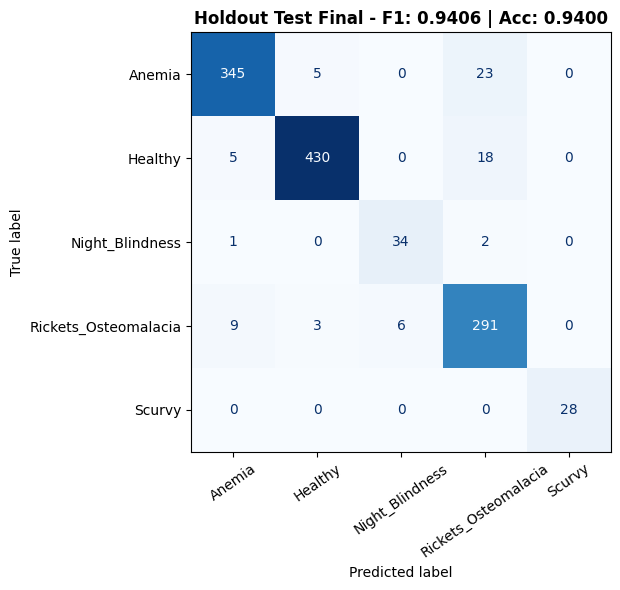

In [28]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_holdout, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_final.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(
    f'Holdout Test Final - F1: {f1:.4f} | Acc: {acc:.4f}',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('holdout_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Comparaison V4 vs V5
comparaison = pd.DataFrame({
    'Version'       : ['V4 (meme test set)', 'V5 (holdout honnete)'],
    'Configuration' : ['Bio + Symp + Lifestyle', 'Bio + Symp + Lifestyle'],
    'Test F1'       : [0.9665, round(f1, 4)],
    'Test Accuracy' : [0.9663, round(acc, 4)],
    'Biaise ?'      : ['Oui (vu plusieurs fois)', 'Non (jamais utilise)']
})
print(comparaison.to_string(index=False))

             Version          Configuration  Test F1  Test Accuracy                Biaise ?
  V4 (meme test set) Bio + Symp + Lifestyle   0.9665         0.9663 Oui (vu plusieurs fois)
V5 (holdout honnete) Bio + Symp + Lifestyle   0.9406         0.9400    Non (jamais utilise)


---
## Section 5 — Sauvegarde & Conclusion

In [31]:
# Sauvegarde du modèle final
os.makedirs('models_final', exist_ok=True)

with open('models_final/random_forest_final.pkl', 'wb') as f:
    pickle.dump(rf_final, f)
with open('models_final/scaler_final.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('models_final/label_encoder_final.pkl', 'wb') as f:
    pickle.dump(le_final, f)
with open('models_final/feature_cols_final.pkl', 'wb') as f:
    pickle.dump(cols_final, f)

print('Modele sauvegarde dans models_final/ :')
print('  random_forest_final.pkl')
print('  scaler_final.pkl')
print('  label_encoder_final.pkl')
print('  feature_cols_final.pkl')

Modele sauvegarde dans models_final/ :
  random_forest_final.pkl
  scaler_final.pkl
  label_encoder_final.pkl
  feature_cols_final.pkl


In [33]:
# Conclusion finale

print('  CONCLUSION FINALE V5')

print(f"""
Configuration finale retenue (issue de l'ablation study V4) :
  Features      : Bio + Symptomes + Lifestyle ({len(cols_final)} features)
  SMOTE         : active
  Normalisation : activee
  Algorithme    : Random Forest (meilleurs params V3)

Resultats sur holdout test (30%, jamais utilise avant) :
  Accuracy : {acc:.4f}
  F1 score : {f1:.4f}

Ces resultats sont une estimation NON BIAISEE des performances
reelles du modele sur de nouvelles donnees.
""")

  CONCLUSION FINALE V5

Configuration finale retenue (issue de l'ablation study V4) :
  Features      : Bio + Symptomes + Lifestyle (30 features)
  SMOTE         : active
  Normalisation : activee
  Algorithme    : Random Forest (meilleurs params V3)

Resultats sur holdout test (30%, jamais utilise avant) :
  Accuracy : 0.9400
  F1 score : 0.9406

Ces resultats sont une estimation NON BIAISEE des performances
reelles du modele sur de nouvelles donnees.



## Conclusion Générale — Projet Modèles IA v5

Ce notebook constitue l'**évaluation finale et non biaisée** du modèle de classification
des carences en vitamines, développé progressivement de la V1 à la V5.

### Ce qui a été fait
- Construction itérative du modèle sur 5 versions (ablation study, tuning, SMOTE)
- Identification de la meilleure configuration : **Bio + Symptômes + Lifestyle (30 features)**
- Validation sur un **holdout set indépendant** (30%, seed 999, jamais utilisé avant)

### Résultats finaux retenus

| Métrique | Valeur |
|----------|--------|
| Accuracy | **94.00%** |
| F1 score (weighted) | **94.06%** |

### Points forts du modèle
- **Scurvy** : détection parfaite (F1 = 1.00) grâce à des marqueurs biologiques très distincts
- **Healthy** : très haute précision (0.98), peu de faux positifs
- **Night_Blindness** : bonne détection malgré un support faible (37 cas)

### Limite principale
- Confusion résiduelle entre **Anemia** et **Rickets_Osteomalacia** (23 cas),
  deux pathologies partageant des symptômes de carence proches

### Conclusion
Les performances obtenues sur le holdout (94%) représentent une **estimation réaliste**
des capacités du modèle face à de nouvelles données.
La chute observée par rapport à la V4 (96.65% → 94.06%) n'est pas une régression :
elle reflète la correction du biais de sélection du test set.
